This notebook performs binary classification using historical scada data, with alarm data used as the target label. The data is preprocessed, split into training and testing sets, and transformed into sequences for an LSTM model. The trained model is evaluated using performance metrics, and SHAP is applied to explain the model predictions.

The alarm tag that used here is (OGREY1_INNTAK_RIST_FALLTAP_HH_AL).This alarm is triggered when the intake grate in the reservoir becomes obstructed.


In [1]:
# We used google collab, so in order to load the dataset, we first need to mount the drive.
# import the google drive

from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir('/content/drive/MyDrive/Binary_Alarm_Prediction/OGREY1_INNTAK_RIST_FALLTAP_HH_AL')

Mounted at /content/drive


['cleaned_INNTAK_RIST_FALLTAP_HH_AL.csv',
 'Inntak_RIST_HH_AL_SMOTHE.ipynb',
 'cleaned_INNTAK_RIST_FALLTAP_HH_AL _edit.csv',
 'Inntak_RIST_HH_AL_LSTM_SHAP.ipynb']

In [75]:
# import all the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision, Recall, AUC
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc
import shap





In [4]:

# load the alarm log dataset
df_alarm= pd.read_csv('/content/drive/MyDrive/Binary_Alarm_Prediction/clean_alarmlogg/clean_alarm_data.csv')

In [5]:
# load the historical data for alarm tag
df= pd.read_csv('/content/drive/MyDrive/Binary_Alarm_Prediction/OGREY1_INNTAK_RIST_FALLTAP_HH_AL/cleaned_INNTAK_RIST_FALLTAP_HH_AL.csv',sep=",",dtype=str,engine="python")


In [6]:
df_alarm.columns

Index(['ACK_TS', 'ALARMDESC', 'CATEGORY', 'id', 'TAG', 'ON_TS', 'OFF_TS'], dtype='object')

In [7]:
df.columns

Index(['DateTime', 'RIST_MAKS_SP_LAST', 'RIST_AUTO_DIFF_SP_LAST(cm)',
       'RIST_FALLTAP_PV(cm)', 'RIST_MAKS_PADRAG_SP_LAST(%)',
       'RIST_AUTT_DIFF_TM_PV(cm)'],
      dtype='object')

In [8]:
# Filter alarm records for the selected tag (2024–2025)

df_alarm["ACK_TS"] = pd.to_datetime(df_alarm["ACK_TS"])

df_filter_tag = df_alarm[
    (df_alarm["TAG"] == "OGREY1_INNTAK_RIST_FALLTAP_HH_AL") &
    (df_alarm["ACK_TS"] >= "2024-01-01") &
    (df_alarm["ACK_TS"] < "2025-01-01")].copy()

In [9]:
df.shape

(8785, 6)

In [12]:
df_filter_tag.shape

(89, 7)

In [13]:
#Convert ACK_TSto  datetime format

df_alarm["ACK_TS"] = pd.to_datetime(df_alarm["ACK_TS"])

# create a copy of historical dataset for further analysis
df_work=df.copy()

df_work["DateTime"] = pd.to_datetime(df_work["DateTime"])

#create a column Class in df_work dataset
df_work["alarm"] = 0
alarm_times = df_alarm["ACK_TS"]
rounded_alarm=alarm_times.dt.floor("H")
df_work.loc[df_work["DateTime"].isin(rounded_alarm), "alarm"] = 1


/tmp/ipykernel_30630/4278003656.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rounded_alarm=alarm_times.dt.floor("H")


In [15]:
# Shows the historical dataset with extra column Alarm

df_work.head(5)

,DateTime,RIST_MAKS_SP_LAST,RIST_AUTO_DIFF_SP_LAST(cm),RIST_FALLTAP_PV(cm),RIST_MAKS_PADRAG_SP_LAST(%),RIST_AUTT_DIFF_TM_PV(cm),alarm
0,2023-12-31 23:00:00,5.0,65.0,18.436802758166667,80.0,65.0,0
1,2024-01-01 00:00:00,5.0,65.0,23.301624721745004,80.0,65.0,1
2,2024-01-01 01:00:00,5.0,65.0,31.4727804385,80.0,65.0,0
3,2024-01-01 02:00:00,5.0,65.0,32.6974487315,80.0,65.0,0
4,2024-01-01 03:00:00,5.0,65.0,34.262388017333336,80.0,65.0,1


In [16]:
print(df_work['DateTime'].min())
print(df_work['DateTime'].max())

2023-12-31 23:00:00
2024-12-31 23:00:00


In [ ]:
# Display the distribution of binary class labels (0 and 1)
df_work['alarm'].value_counts()

,count
alarm,
0,7004
1,1781


In [ ]:
df_work.head(5)

,DateTime,RIST_MAKS_SP_LAST,RIST_AUTO_DIFF_SP_LAST(cm),RIST_FALLTAP_PV(cm),RIST_MAKS_PADRAG_SP_LAST(%),RIST_AUTT_DIFF_TM_PV(cm),alarm
0,2023-12-31 23:00:00,5.0,65.0,18.436802758166667,80.0,65.0,0
1,2024-01-01 00:00:00,5.0,65.0,23.301624721745004,80.0,65.0,1
2,2024-01-01 01:00:00,5.0,65.0,31.4727804385,80.0,65.0,0
3,2024-01-01 02:00:00,5.0,65.0,32.6974487315,80.0,65.0,0
4,2024-01-01 03:00:00,5.0,65.0,34.262388017333336,80.0,65.0,1


In [17]:
# Monthly distribution of binary classes (0 and 1)

df_work["DateTime"] = pd.to_datetime(df_work["DateTime"])
df_work["month"] = df_work["DateTime"].dt.to_period("M")
df_work.groupby("month")["alarm"].value_counts().unstack(fill_value=0)

alarm,0,1
month,,
2023-12,1,0
2024-01,690,54
2024-02,696,0
2024-03,605,139
2024-04,570,150
2024-05,642,102
2024-06,682,38
2024-07,566,178
2024-08,490,254


In [19]:
df_work.columns

Index(['DateTime', 'RIST_MAKS_SP_LAST', 'RIST_AUTO_DIFF_SP_LAST(cm)',
       'RIST_FALLTAP_PV(cm)', 'RIST_MAKS_PADRAG_SP_LAST(%)',
       'RIST_AUTT_DIFF_TM_PV(cm)', 'alarm', 'month'],
      dtype='object')

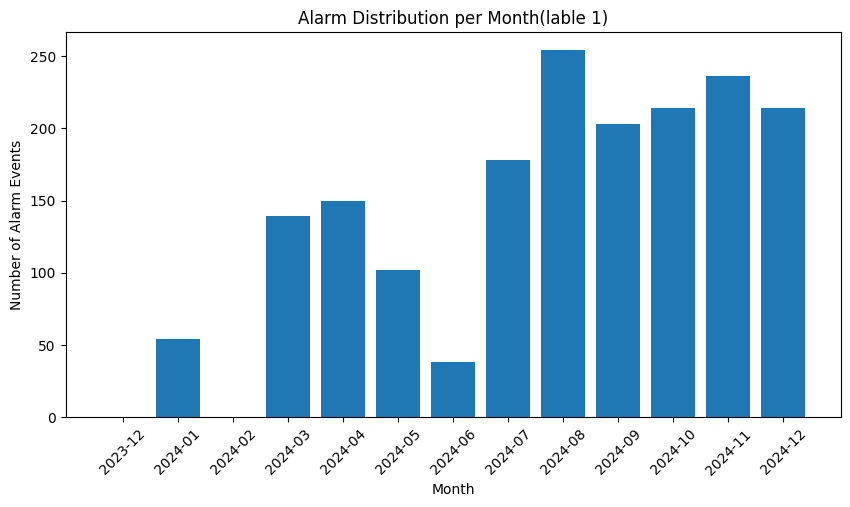

In [21]:

# Count alarms per month
monthly_counts = df_work.groupby("month")["alarm"].sum()

# Convert month format to string
monthly_counts.index = monthly_counts.index.astype(str)

# Bar plot
plt.figure(figsize=(10,5))
plt.bar(monthly_counts.index, monthly_counts.values)

plt.xlabel("Month")
plt.ylabel("Number of Alarm Events")
plt.title("Alarm Distribution per Month(lable 1)")

plt.xticks(rotation=45)
plt.show()


In [22]:
# # Separate the feature columns and the DateTime column for further processing

feature_cols = ['RIST_MAKS_SP_LAST', 'RIST_AUTO_DIFF_SP_LAST(cm)','RIST_FALLTAP_PV(cm)','RIST_MAKS_PADRAG_SP_LAST(%)','RIST_AUTT_DIFF_TM_PV(cm)']
df_work[feature_cols] = df_work[feature_cols].astype(str).apply(
    lambda col: col.str.strip().str.replace(",", ".", regex=False))
df_work[feature_cols] = df_work[feature_cols].apply(pd.to_numeric, errors="coerce")

### Correlation Analysis: The correlation matrix was computed to show the strength and direction of relationships between numerical features of dataset.
### Red indicates positive correlation, while blue indicates negative correlation

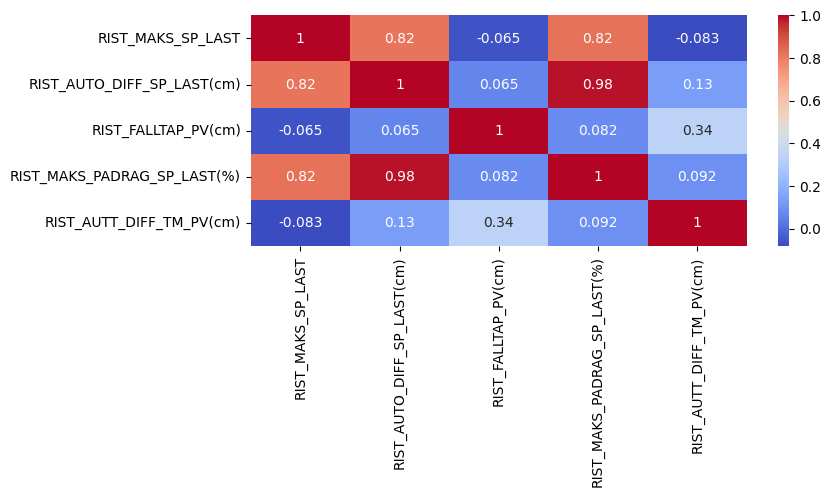

In [24]:
corr = df_work[feature_cols].corr()
corr = df_work[feature_cols].corr()
plt.figure(figsize=(8,3))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [25]:
# Split the data into training and testing sets

split_date = "2024-11-30"

train = df_work[df_work["DateTime"] < split_date]
test  = df_work[df_work["DateTime"] >= split_date]

In [ ]:
# Apply feature scaling to the dataset
feature_cols = ['RIST_MAKS_SP_LAST', 'RIST_AUTO_DIFF_SP_LAST(cm)','RIST_FALLTAP_PV(cm)','RIST_MAKS_PADRAG_SP_LAST(%)','RIST_AUTT_DIFF_TM_PV(cm)']

scaler = StandardScaler() # compute Mean and SD
train[feature_cols] = scaler.fit_transform(train[feature_cols])
test[feature_cols] = scaler.transform(test[feature_cols])

### **Create sequences using a sliding window for LSTM input**


In [28]:
# Create LSTM sequences using a sliding window of 24 timesteps

window = 24

def make_sequences(df_work, feature_cols, target_col="alarm", window=24):
    X, y = [], []  # Empty lists to store inputs and targets
    values = df_work[feature_cols].values  # Get feature data as numpy array
    alarms = df_work[target_col].values     # Get target(alarm 0/1) as numpy array

    for i in range(len(df_work) - window):
        X.append(values[i:i+window])
        y.append(alarms[i+window])

    return np.array(X), np.array(y)    # convert list to array and return

X_train, y_train = make_sequences(train, feature_cols, "alarm", window)
X_test, y_test = make_sequences(test, feature_cols, "alarm", window)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(7993, 24, 5) (7993,)
(744, 24, 5) (744,)


In [29]:
print("Train:")
print(pd.Series(y_train).value_counts())

print("Test:")
print(pd.Series(y_test).value_counts())

Train:
0    6434
1    1559
Name: count, dtype: int64
Test:
0    530
1    214
Name: count, dtype: int64


### **Validation sets**

In [31]:
# Divide the training data into train and validation sets

val_size = int(len(X_train) * 0.2)

X_val = X_train[-val_size:]
y_val = y_train[-val_size:]

X_train2 = X_train[:-val_size]
y_train2 = y_train[:-val_size]

## **Builds the model architecture (structure)**





In [34]:

# Build the LSTM model architecture, shape 24 and 5(features )

model = Sequential([
    LSTM(64,input_shape=(24, 5)),
    Dropout(0.2),

   BatchNormalization(),

    Dense(32, activation="relu"),
    Dropout(0.2),


    Dense(1, activation="sigmoid")
])

# Compile the model with the optimizer, loss function, and metrics
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="auc")
]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,161 (78.75 KB)

 Non-trainable params: 128 (512.00 B)

## **Train the model on the training data**
###Training results may vary slightly between runs due to dropout and random weight initialization.

In [47]:

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

#class_weight = {0: 1, 1:10}
history = model.fit(
    X_train2, y_train2,
    validation_data=(X_val, y_val),
    epochs=100,         # number of training cycles
    batch_size=32,      # Number of samples processed at once
    callbacks=[early_stopping],
    #class_weight=class_weight,
    shuffle=False
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8319 - auc: 0.5841 - loss: 0.4579 - precision: 0.4511 - recall: 0.0565 - val_accuracy: 0.6859 - val_auc: 0.4924 - val_loss: 0.8138 - val_precision: 0.4843 - val_recall: 0.1549
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8325 - auc: 0.6008 - loss: 0.4500 - precision: 0.4667 - recall: 0.0593 - val_accuracy: 0.6615 - val_auc: 0.5364 - val_loss: 0.7388 - val_precision: 0.4035 - val_recall: 0.1851
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8350 - auc: 0.6166 - loss: 0.4448 - precision: 0.5259 - recall: 0.0669 - val_accuracy: 0.6615 - val_auc: 0.5336 - val_loss: 0.7836 - val_precision: 0.4068 - val_recall: 0.1932
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8344 - auc: 0.6327 - loss: 0.4387 - precision: 0.5120 - recall: 0.0603 - val_accuracy: 0.7015 - val_auc: 0.5105 - val_loss: 0.9239 - val_precision: 0.5962 - val_recall: 0.1247
Epoch 5/100
200/200 ━━━━

##**Final evaluation**

In [48]:
model.evaluate(X_test, y_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6909 - auc: 0.4794 - loss: 0.7394 - precision: 0.4070 - recall: 0.1636


[0.7394405007362366,
 0.6908602118492126,
 0.40697672963142395,
 0.16355140507221222,
 0.47944366931915283]

In [49]:

# Predict probabilities once
y_prob = model.predict(X_test)

# Test different classification thresholds
for t in [0.35, 0.04, 0.045, 0.05]:
    print(f"\nThreshold: {t}")

    y_pred = (y_prob > t).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("Precision:", round(precision, 3))
    print("Recall:", round(recall, 3))
    print("F1:", round(f1, 3))

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Threshold: 0.35
[[353 177]
 [138  76]]
Precision: 0.3
Recall: 0.355
F1: 0.325

Threshold: 0.04
[[ 77 453]
 [ 30 184]]
Precision: 0.289
Recall: 0.86
F1: 0.432

Threshold: 0.045
[[ 77 453]
 [ 32 182]]
Precision: 0.287
Recall: 0.85
F1: 0.429

Threshold: 0.05
[[ 78 452]
 [ 33 181]]
Precision: 0.286
Recall: 0.846
F1: 0.427


The AUC value indicates the model's ability to distinguish between the positive and negative classes. A higher AUC value reflects better classification performance:

AUC = 0.50         >> The model performs like random guessing

AUC = 0.70–0.80    >>  Acceptable performance

AUC = 0.80–0.90    >> Good performance.

AUC > 0.90         >> Excellent performance.

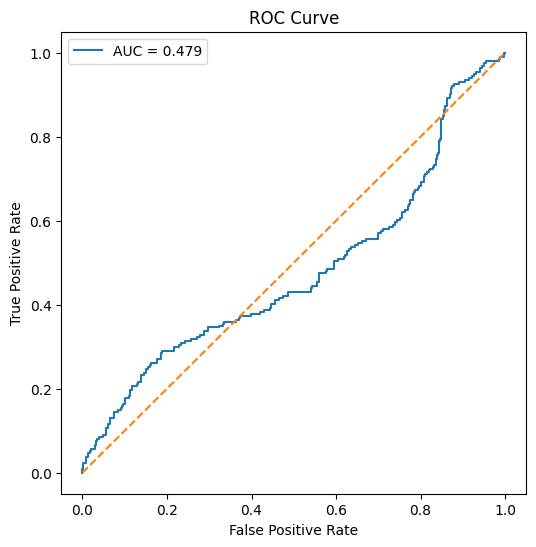

In [51]:
# Compute ROC curve and AUC
#tpr (True Positive Rate), fpr (False Positive Rate)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

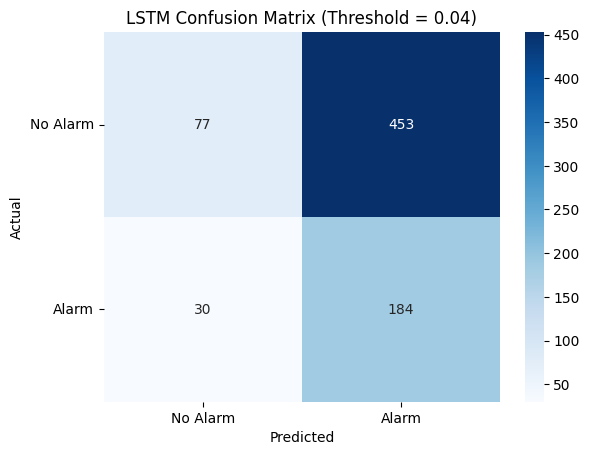

In [52]:

# matrix
cm = np.array([[77, 453], [30, 184]])

plt.figure()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix (Threshold = 0.04)")

plt.xticks([0.5, 1.5], ['No Alarm', 'Alarm'])
plt.yticks([0.5, 1.5], ['No Alarm', 'Alarm'], rotation=0)

plt.show()

In [58]:
!pip install shap

**SHAP Analysis:**
Use SHAP to explain the LSTM model predictions and identify the most important features affecting the output.

In [76]:
print("X_train2:", X_train2.shape)
print("X_test:", X_test.shape)
print("Features:", feature_cols)

X_train2: (6395, 24, 5)
X_test: (744, 24, 5)
Features: ['RIST_MAKS_SP_LAST', 'RIST_AUTO_DIFF_SP_LAST(cm)', 'RIST_FALLTAP_PV(cm)', 'RIST_MAKS_PADRAG_SP_LAST(%)', 'RIST_AUTT_DIFF_TM_PV(cm)']


In [77]:
# Select a subset of training data as the SHAP background dataset
reference_sample = X_train2[:100]

# Select test samples to explain
X_explain = X_test[:50]

#Create a SHAP GradientExplainer for the trained LSTM model
explainer = shap.GradientExplainer(model, reference_sample)

#Compute SHAP values for the selected test samples
shap_values = explainer.shap_values(X_explain)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_14
Received: inputs=['Tensor(shape=(50, 24, 5))']
  warnings.warn(msg)


In [81]:
if isinstance(shap_values, list):
    shap_values_array = shap_values[0]
else:
    shap_values_array = shap_values
print(shap_values_array.shape)

(50, 24, 5, 1)


In [82]:
# removing the extra dimension
shap_values_array = np.squeeze(shap_values_array, axis=-1)

print(shap_values_array.shape)

(50, 24, 5)


In [84]:
# Take absolute SHAP values (np.abs)
# Average them across all observations (np.mean(axis=0)).
# Get one importance score per feature
feature_importance = np.mean(np.abs(shap_values_array), axis=(0, 1))

for name, value in zip(feature_cols, feature_importance):
    print(name, value)

RIST_MAKS_SP_LAST 0.0
RIST_AUTO_DIFF_SP_LAST(cm) 0.0006283420666250095
RIST_FALLTAP_PV(cm) 0.00030296569755745866
RIST_MAKS_PADRAG_SP_LAST(%) 0.00023970011164410406
RIST_AUTT_DIFF_TM_PV(cm) 0.000191402563768861


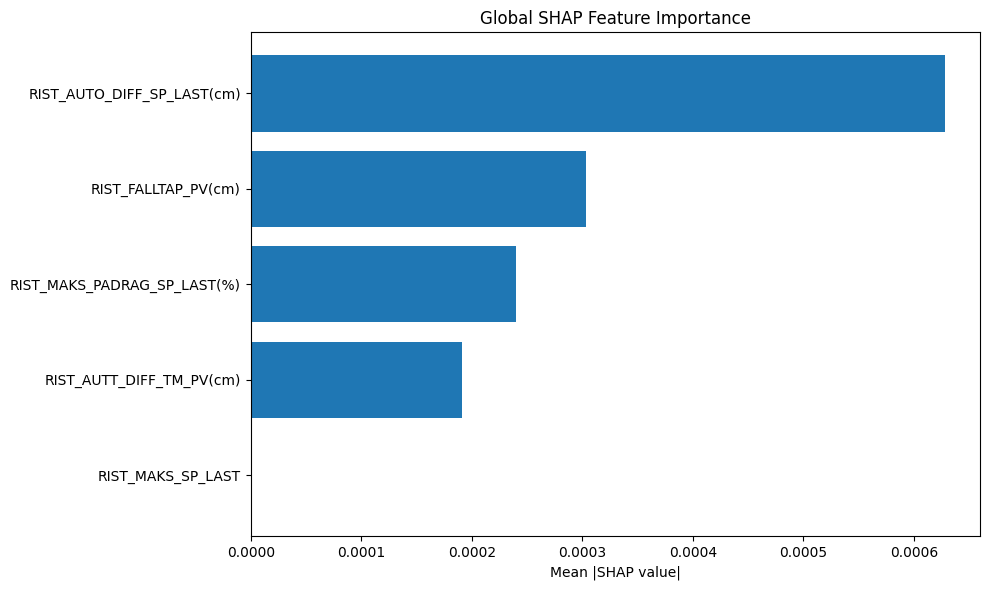

In [85]:
# Global SHAP identifies the most important features by averaging SHAP values across all samples.


importance_df = pd.DataFrame({"Feature": feature_cols, "Importance": feature_importance})

importance_df = importance_df.sort_values("Importance", ascending=True)

plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])

plt.xlabel("Mean |SHAP value|")
plt.title("Global SHAP Feature Importance")

plt.tight_layout()
plt.show()

SHAP Summary (beeswarm) Plot: Displays the impact of each feature on the model's predictions. Features are ranked by importance, and the color represents the feature value (blue = low, pink = high)

/tmp/ipykernel_30630/3205138586.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_array.reshape(-1, 5), X_explain.reshape(-1, 5), feature_names=feature_cols)


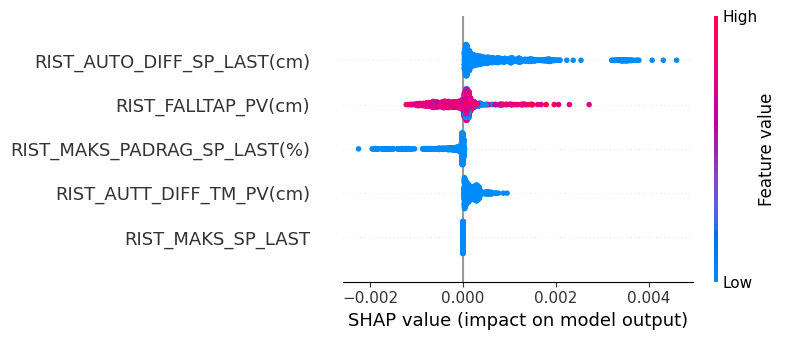

In [87]:

shap.summary_plot(shap_values_array.reshape(-1, 5), X_explain.reshape(-1, 5), feature_names=feature_cols)